## Note Book for analysis

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
pd.set_option('future.no_silent_downcasting', True)

### Load Data

In [2]:
df=sns.load_dataset("tips")

### Download dataset

In [ ]:
df.to_csv('../data/tips.csv',index=False)

### Distribution of total bills

- What is the most common total bill range?
- How does the distribution differ between lunch and dinner?


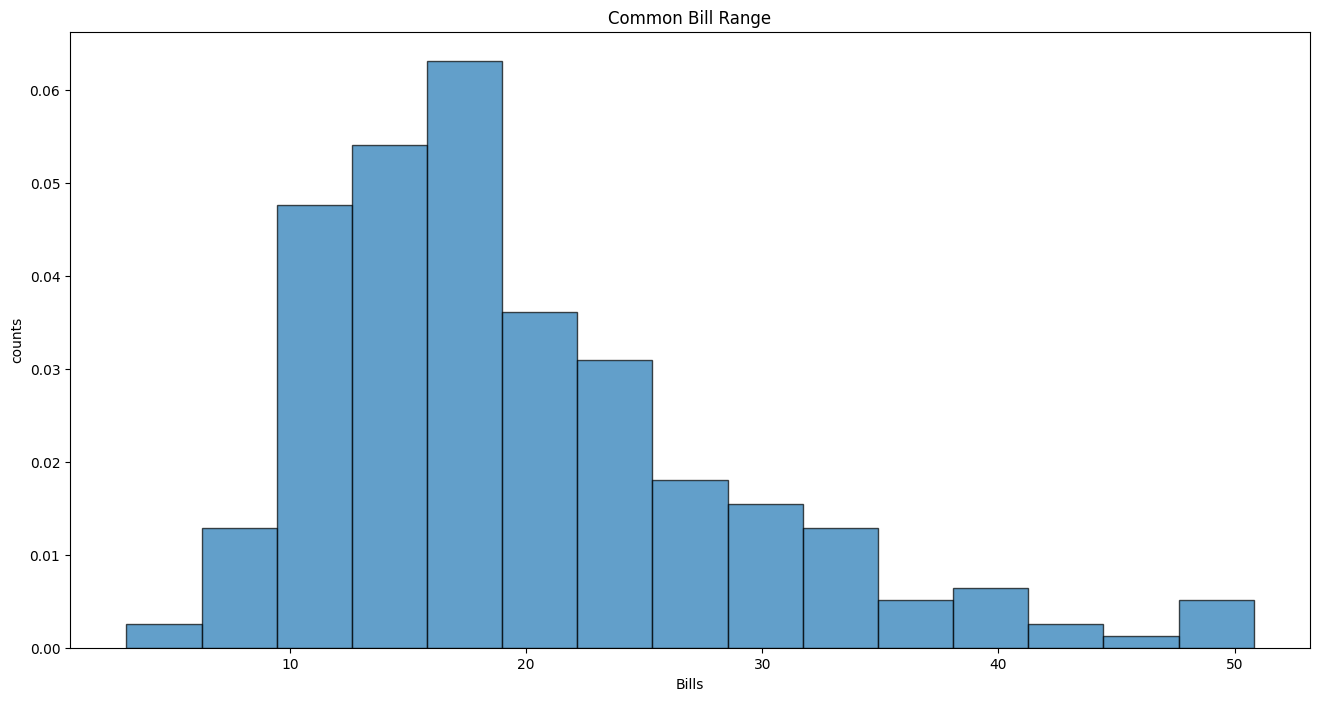

In [ ]:
fig ,ax =plt.subplots(figsize=(16,8))
ax.hist(df['total_bill'],bins=15, edgecolor='black', alpha=0.7,density=True)
ax.set_xlabel("Bills")
ax.set_ylabel("counts")
ax.set_title("Common Bill Range")
#plt.savefig('../pictures/bill.png',dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**  Most payed bill range $10-$20

**Distribution of  Dinner and Lunch time Total bill**

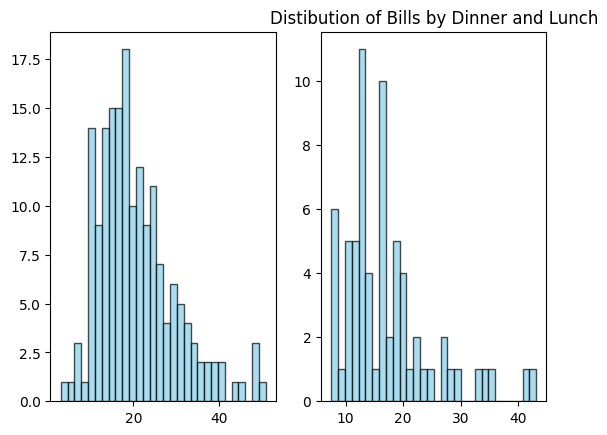

In [3]:
fig , ax= plt.subplots(ncols=2,nrows=1)
# dinner Time 
dinnerdf=df[df['time']=='Dinner']
Lunchdf=df[df['time']=='Lunch']
ax[0].hist(dinnerdf['total_bill'],bins=30,color='skyblue', edgecolor='black', alpha=0.7)
ax[1].hist(Lunchdf['total_bill'],bins=30,color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distibution of Bills by Dinner and Lunch")
plt.savefig('../pictures/bill_at_dinner_lunch.png')
plt.show()


**Key insight**: At lunch and Dinner Time The most bill payed in $10-$20 range.

### Average tip By Day

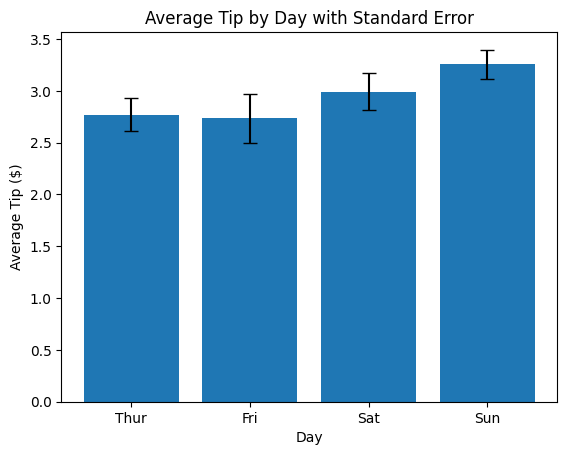

In [ ]:
grouped=df.groupby('day',observed=False)['tip']
tip_mean=grouped.mean()
tip_std=grouped.std()
tip_len=grouped.count()
tip_day=grouped.mean().index
sem=tip_std/np.sqrt(tip_len)
plt.bar(tip_day,tip_mean,yerr=sem,capsize=5)
plt.xlabel('Day')
plt.ylabel('Average Tip ($)')
plt.title('Average Tip by Day with Standard Error')
plt.savefig('../pictures/Average_tip_by_day.png')
plt.show()

**Key insight** :On sunday  Average Tips is slightly high then other days

### Tip percentage by party size
- Do larger parties tip a higher or lower percentage?




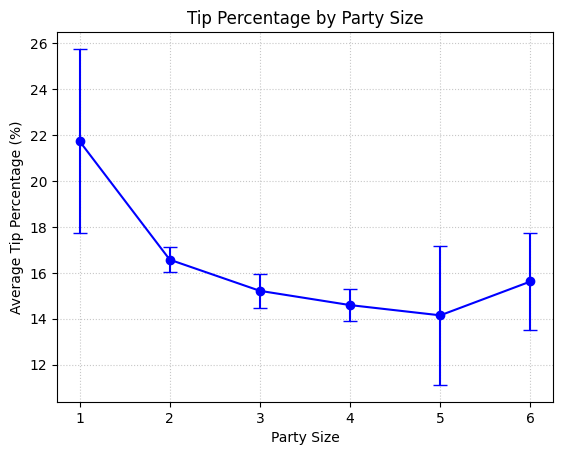

In [24]:
# Tips 
df["percentage_tip"]=(df['tip']/df['total_bill'])*100
grouped=df.groupby('size')['percentage_tip'].agg(['mean','std','count'])
grouped['sem']=grouped['std']/np.sqrt(grouped['count'])
grouped
fig ,ax=plt.subplots()
ax.errorbar(grouped.index , grouped['mean'],yerr=grouped['sem'],marker='o', capsize=5, linestyle='-', color='blue')
ax.set_xlabel('Party Size')
ax.set_ylabel('Average Tip Percentage (%)')
ax.set_title('Tip Percentage by Party Size')
ax.grid(True, linestyle=':', alpha=0.7)
plt.savefig('../graphs/tip_per_by_party_size.png')
plt.show()


**Highest Tip**: The data point for a single person (party size 1) is the highest on the chart, averaging approximately 22%.
**Lowest Tip**: The lowest average tip percentage (around 14%) is observed for a party size of 5 people.

### Tip distribution by time of day
- Which meal time has more variability in tips?

- Are there outliers?

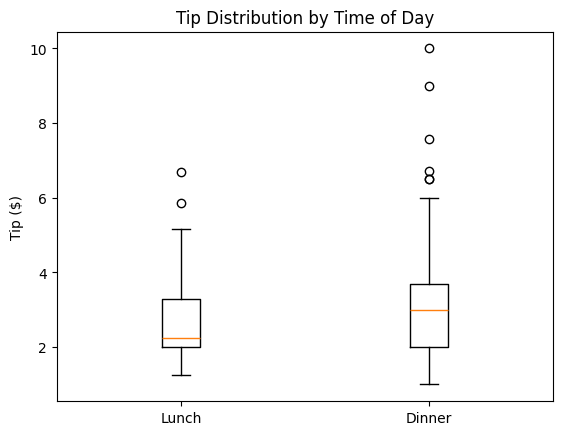

In [25]:
fig ,ax=plt.subplots()
data_to_plot = [df[df['time'] == 'Lunch']['tip'],
                df[df['time'] == 'Dinner']['tip']]

ax.boxplot(data_to_plot,tick_labels=['Lunch','Dinner'])
ax.set_ylabel('Tip ($)')
ax.set_title('Tip Distribution by Time of Day')
plt.savefig('../graphs/tip_at_dinner&lunch.png')
plt.show()


**Lunch Time**: The tips is low and there is small median with  fewers outlier.<br>
**Dinner Time**: The tip is high and there is high midean with more outlier.<br>
**Ket insight**: more chance of high tip at Dinner time.

### Number of customers by day and time
- Which day is busiest?

- Does the pattern differ between lunch and dinner?

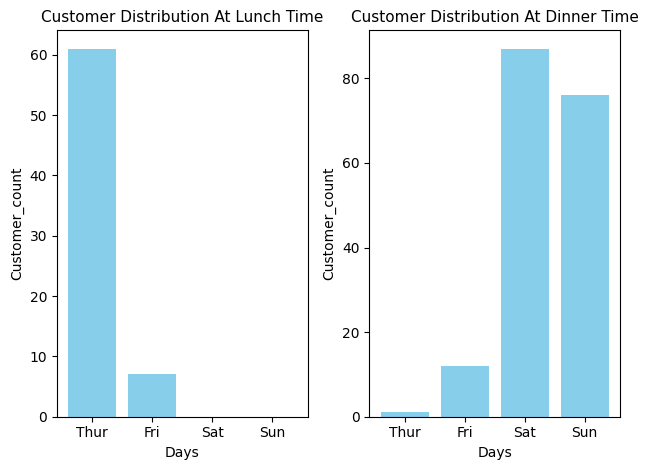

In [26]:
fig , ax = plt.subplots(ncols=2,nrows=1)
Lunch_df=df[df['time'] == 'Lunch']
customer_day_lunch=Lunch_df.groupby('day',observed=False).size()
ax[0].bar(customer_day_lunch.index,customer_day_lunch,color='skyblue')
ax[0].set_xlabel("Days")
ax[0].set_ylabel("Customer_count")
ax[0].set_title("Customer Distribution At Lunch Time", fontsize=11)
# Customer At lunch Time 
Dinner_df=df[df['time'] == 'Dinner']
customer_day_Dinner=Dinner_df.groupby('day',observed=False).size()
ax[1].bar(customer_day_Dinner.index,customer_day_Dinner,color='skyblue')
ax[1].set_xlabel("Days")
ax[1].set_ylabel("Customer_count")
ax[1].set_title("Customer Distribution At Dinner Time", fontsize=11)
plt.savefig('../graphs/customer_at_dinner_lunch.png')
plt.tight_layout()
plt.show()

**Lunch Time**: The number of customer are more on thurisday.<br>
**Dinner Time**: The number of customer are more on saturday and sunday.<br>

- Total bill  by Male and female?
- Do smokers spend more on average?
- total Percentage tip by Day?
- Total bill by smokers and non smokers


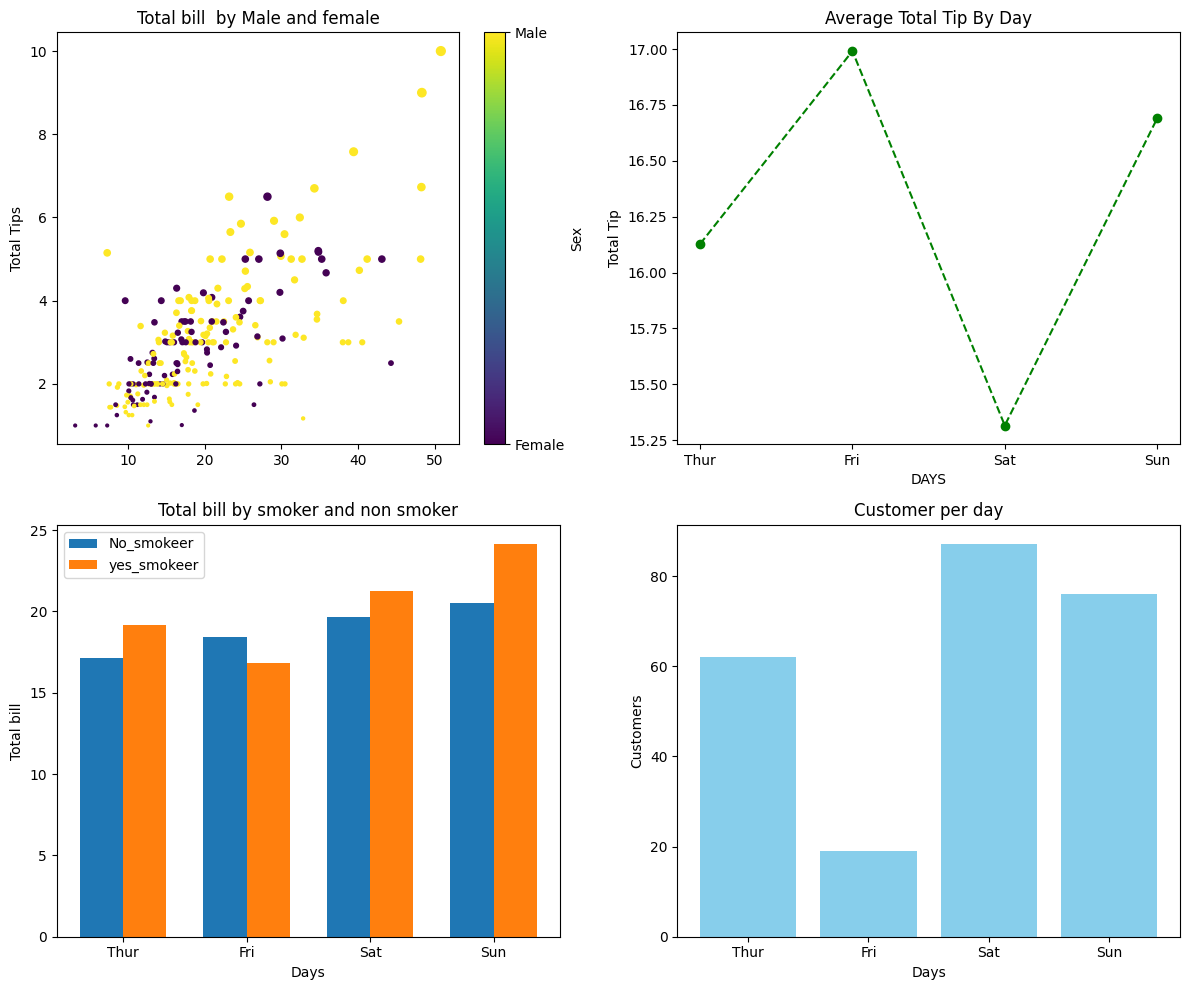

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Total bill  by Male and female
ax1=axes[0,0]
# df['leb'] = df['sex'].replace({"Female": 1, "Male": 2})
df['leb'] = df['sex'].cat.rename_categories({"Female": 1, "Male": 2})
sc =ax1.scatter(df['total_bill'], df['tip'],linewidths=1, s=df['tip']*4, cmap='viridis', c=df['leb'])
ax1.set_ylabel("Total Bill")
ax1.set_ylabel("Total Tips")
ax1.set_title("Total bill  by Male and female")
# Add a colorbar
cbar = plt.colorbar(sc)
cbar.set_ticks([1, 2])
cbar.set_ticklabels(['Female', 'Male'])
cbar.set_label('Sex')
ax2=axes[0,1]
# total Percentage tip by Day
df["percentage_tip"]=(df['tip']/df['total_bill'])*100
Avg_per_tip_day=df.groupby('day', observed=False )['percentage_tip'].mean()
ax2.plot(Avg_per_tip_day.index,Avg_per_tip_day,marker='o',linestyle='--',color='green')
ax2.set_xlabel('DAYS')
ax2.set_ylabel("Total Tip")
ax2.set_title("Average Total Tip By Day")
# Total bill by smokers and non smokers
avg_bill = df.groupby(['day', 'smoker'],observed=False)['total_bill'].mean().unstack()
days = ['Thur', 'Fri', 'Sat', 'Sun']
x = np.arange(4)
width=0.35
ax3=axes[1,0]
ax3.bar(x-width/2,avg_bill['No'],width,label='No_smokeer')
ax3.bar(x+width/2,avg_bill['Yes'],width,label='yes_smokeer')
ax3.set_xlabel("Days")
ax3.set_ylabel("Total bill")
ax3.legend()
ax3.set_title("Total bill by smoker and non smoker")
ax3.set_xticks(x)
ax3.set_xticklabels(days)
# Number of customer by day
customer_day=df.groupby('day',observed=False).size()
ax4=axes[1,1]
ax4.bar(customer_day.index,customer_day,color='skyblue')
ax4.set_xlabel("Days")
ax4.set_ylabel("Customers")
ax4.set_title("Customer per day")
plt.savefig('../pictures/dashed_bord.png')
plt.tight_layout()
plt.show()


**Highest Tip and Bill**: The higest tip and bill is  given by male. <br>
**higest Tip**:  The higest tip is given on friday. <br>
**higest Bill**: The higest bill payed by Smokers. <br>
**Higest customers**: The higest customers are on Satureday.